# O1 fixed-depth performance across dimensions

This notebook compares fixed random-forest depths 5, 10, 15, and 20 on O1 dimensions 5, 10, 25, and 50. Results use two benchmark landscapes and five SMAC seeds.

In [3]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import t

DIMENSIONS = (5, 10, 25, 50)
DEPTHS = (5, 10, 15, 20)
BENCHMARK_SEEDS = (40, 41)
SMAC_SEEDS = tuple(range(5))
N_TRIALS = 1000

candidates = [
    Path.cwd(),
    Path.cwd() / 'experiments/synthaticBench/o1_deterministic/depth_policies/01_dimensions',
]
HERE = next((path for path in candidates if (path / 'o1_dimension_runner.py').exists()), None)
if HERE is None:
    raise FileNotFoundError('Run from the notebook directory or repository root.')
OUTPUT = HERE / 'smac_output'
print(HERE.resolve())


/rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/01_dimensions


## Load and validate trajectories

In [4]:
rows, curves, instance_maps = [], {}, set()
for path in sorted(OUTPUT.rglob('trajectory.json')):
    data = json.loads(path.read_text())
    dimension = int(data['dimension'])
    benchmark_seed = int(data['benchmark_seed'])
    depth = int(data['max_depth'])
    smac_seed = int(data['smac_seed'])
    key = (dimension, benchmark_seed, depth, smac_seed)
    if key in curves:
        raise ValueError(f'Duplicate trajectory: {key}')
    best = np.asarray(data['best_regret'], dtype=float)
    curves[key] = best
    instance_maps.add(tuple(sorted((name, float(value)) for name, value in data['instance_map'].items())))
    rows.append({
        'dimension': dimension,
        'benchmark_seed': benchmark_seed,
        'depth': depth,
        'smac_seed': smac_seed,
        'final_regret': float(best[-1]),
        'mean_regret': float(best.mean()),
        'log_auc': float(np.log10(np.maximum(best, 1e-300)).mean()),
        'n_trials': int(data['n_trials']),
        'n_instances': int(data['n_instances']),
        'instance_std': float(data['instance_standard_deviation']),
        'random_design_probability': float(data['random_design_probability']),
        'pythonhashseed': str(data['pythonhashseed']),
        'path': path,
    })
results = pd.DataFrame(rows)
if results.empty:
    raise FileNotFoundError(f'No trajectories found below {OUTPUT}.')
bad = results.query(
    "n_trials != 1000 or n_instances != 10 or instance_std != 2 "
    "or random_design_probability != 0 or pythonhashseed != '12345'"
)
if not bad.empty:
    display(bad)
    raise ValueError('Incompatible trajectory metadata.')
expected = {
    (dimension, benchmark_seed, depth, smac_seed)
    for dimension in DIMENSIONS
    for benchmark_seed in BENCHMARK_SEEDS
    for depth in DEPTHS
    for smac_seed in SMAC_SEEDS
}
observed = set(curves)
missing, unexpected = expected - observed, observed - expected
print(f'Loaded {len(observed)}/{len(expected)} trajectories.')
if missing:
    display(pd.DataFrame(sorted(missing), columns=['dimension', 'benchmark_seed', 'depth', 'smac_seed']))
if unexpected:
    display(pd.DataFrame(sorted(unexpected), columns=['dimension', 'benchmark_seed', 'depth', 'smac_seed']))
assert not missing and not unexpected
assert len(instance_maps) == 1, 'Instance offsets differ between runs.'
assert all(len(curve) == N_TRIALS for curve in curves.values())
display(
    results.groupby(['benchmark_seed', 'dimension', 'depth'])
    .smac_seed.nunique().unstack(fill_value=0)
)


Loaded 160/160 trajectories.


depth                     5   10  15  20
benchmark_seed dimension                
40             5           5   5   5   5
               10          5   5   5   5
               25          5   5   5   5
               50          5   5   5   5
41             5           5   5   5   5
               10          5   5   5   5
               25          5   5   5   5
               50          5   5   5   5

## Best-regret trajectories with 95% confidence intervals

Each line is the mean incumbent simple regret over five SMAC seeds. Shading is the two-sided 95% Student-t confidence interval for that mean. All eight panels use the same logarithmic y-axis limits, making vertical scales directly comparable.

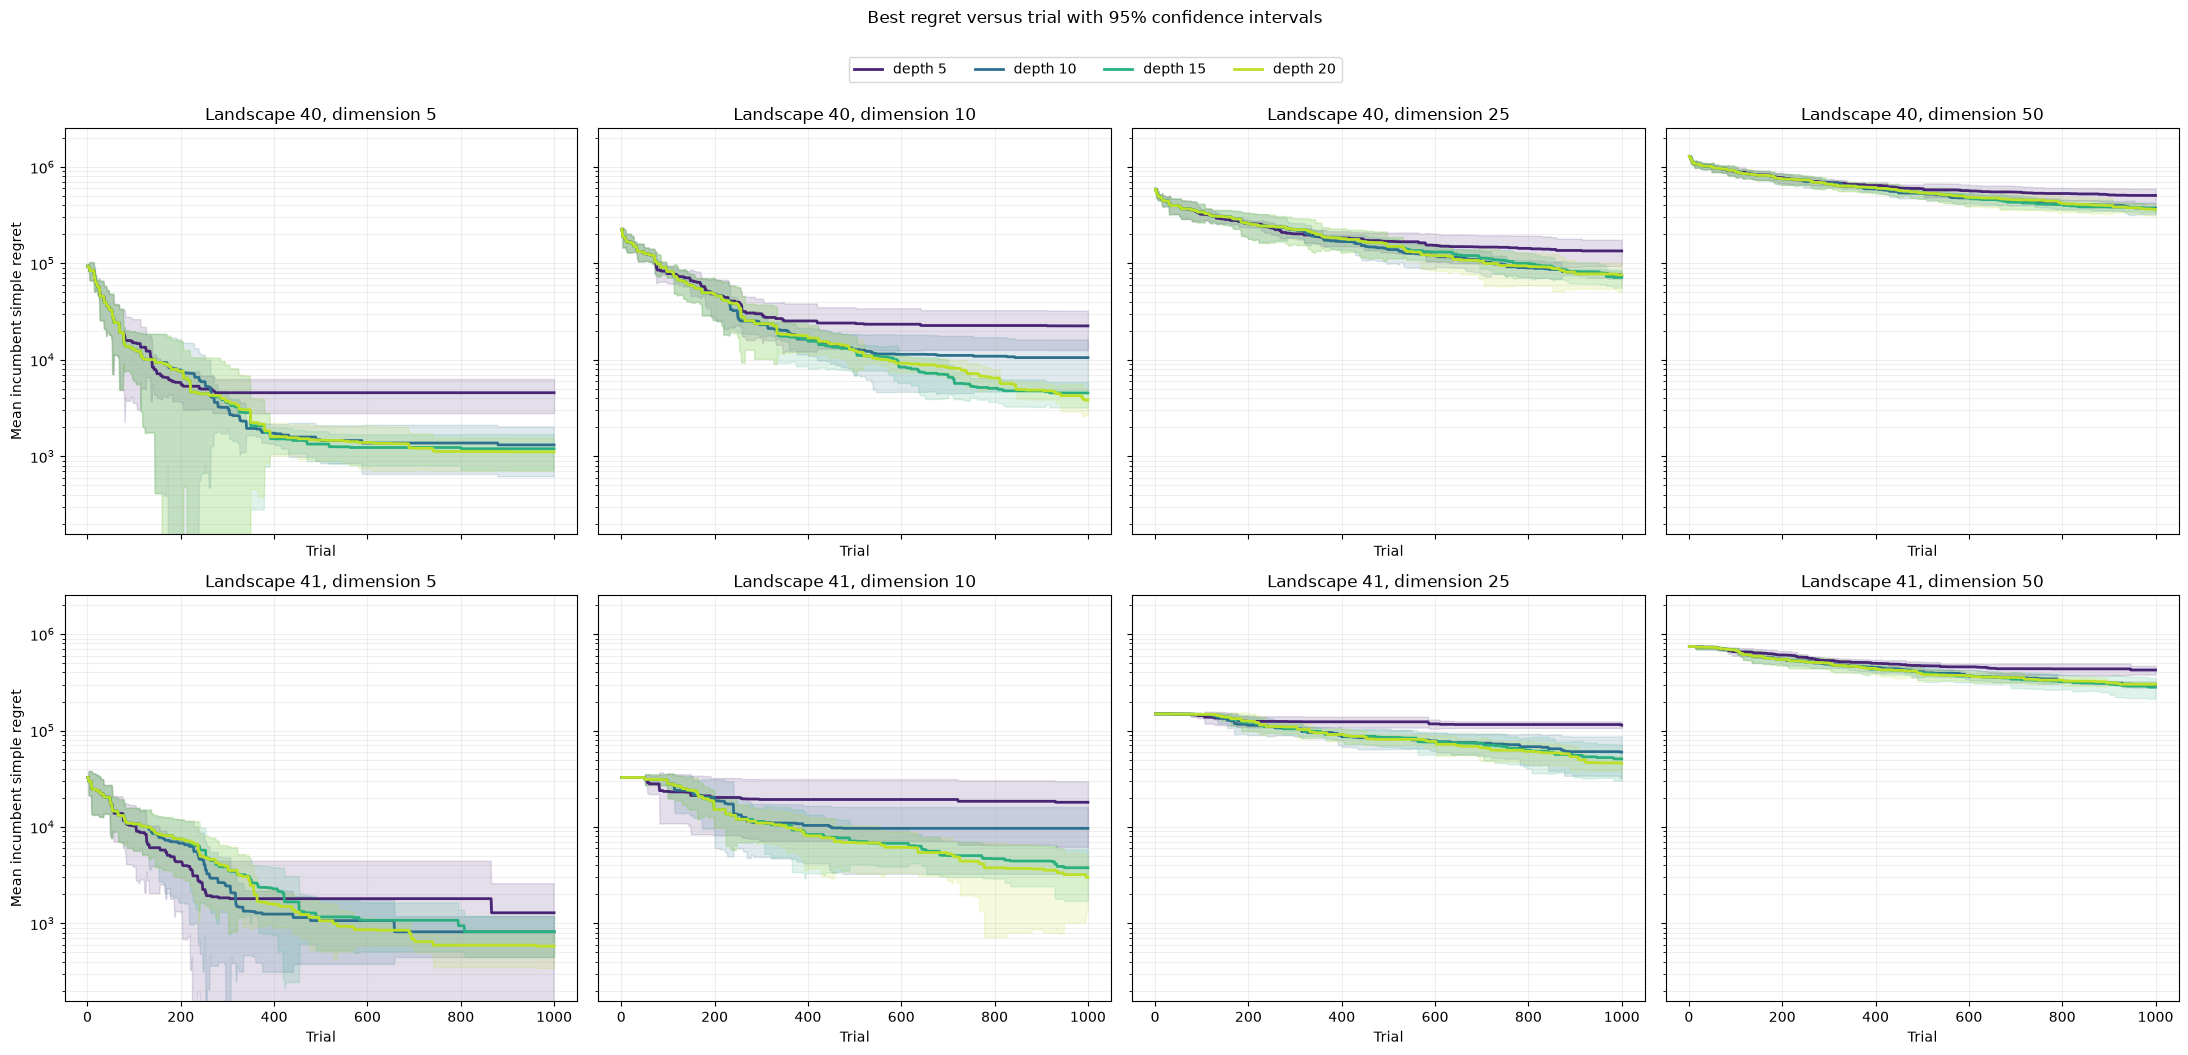

In [5]:
colors = dict(zip(DEPTHS, plt.cm.viridis(np.linspace(0.1, 0.9, len(DEPTHS)))))
x = np.arange(1, N_TRIALS + 1)

def padded_log_limits(values, padding_decades=0.08):
    positive = np.concatenate([np.asarray(value, float).ravel() for value in values])
    positive = positive[np.isfinite(positive) & (positive > 0)]
    if not len(positive):
        raise ValueError('Cannot determine logarithmic limits without positive values.')
    low, high = np.log10(positive.min()), np.log10(positive.max())
    padding = max((high - low) * padding_decades, 0.05)
    return 10 ** (low - padding), 10 ** (high + padding)

trajectory_y_limits = padded_log_limits(list(curves.values()))
fig, axes = plt.subplots(
    len(BENCHMARK_SEEDS), len(DIMENSIONS),
    figsize=(22, 10), sharex=True, sharey=True,
)
for row, benchmark_seed in enumerate(BENCHMARK_SEEDS):
    for column, dimension in enumerate(DIMENSIONS):
        ax = axes[row, column]
        for depth in DEPTHS:
            matrix = np.vstack([
                curves[(dimension, benchmark_seed, depth, smac_seed)]
                for smac_seed in SMAC_SEEDS
            ])
            mean = matrix.mean(axis=0)
            sem = matrix.std(axis=0, ddof=1) / np.sqrt(len(SMAC_SEEDS))
            margin = t.ppf(0.975, len(SMAC_SEEDS) - 1) * sem
            ax.plot(x, np.maximum(mean, 1e-300), color=colors[depth], lw=2, label=f'depth {depth}')
            ax.fill_between(
                x, np.maximum(mean - margin, 1e-300),
                np.maximum(mean + margin, 1e-300),
                color=colors[depth], alpha=0.15,
            )
        ax.set_yscale('log')
        ax.set_ylim(*trajectory_y_limits)
        ax.set_title(f'Landscape {benchmark_seed}, dimension {dimension}')
        ax.set_xlabel('Trial')
        ax.set_ylabel('Mean incumbent simple regret' if column == 0 else '')
        ax.grid(alpha=0.2, which='both')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(DEPTHS), bbox_to_anchor=(0.5, 1.01))
fig.suptitle('Best regret versus trial with 95% confidence intervals', y=1.05)
fig.tight_layout()
plt.show()


## Final-regret boxplots

Each box contains final regret at trial 1,000 for the five paired SMAC seeds. Dots show individual runs. All panels share logarithmic y-axis limits, separate from the trajectory limits so early regret does not compress the boxes.

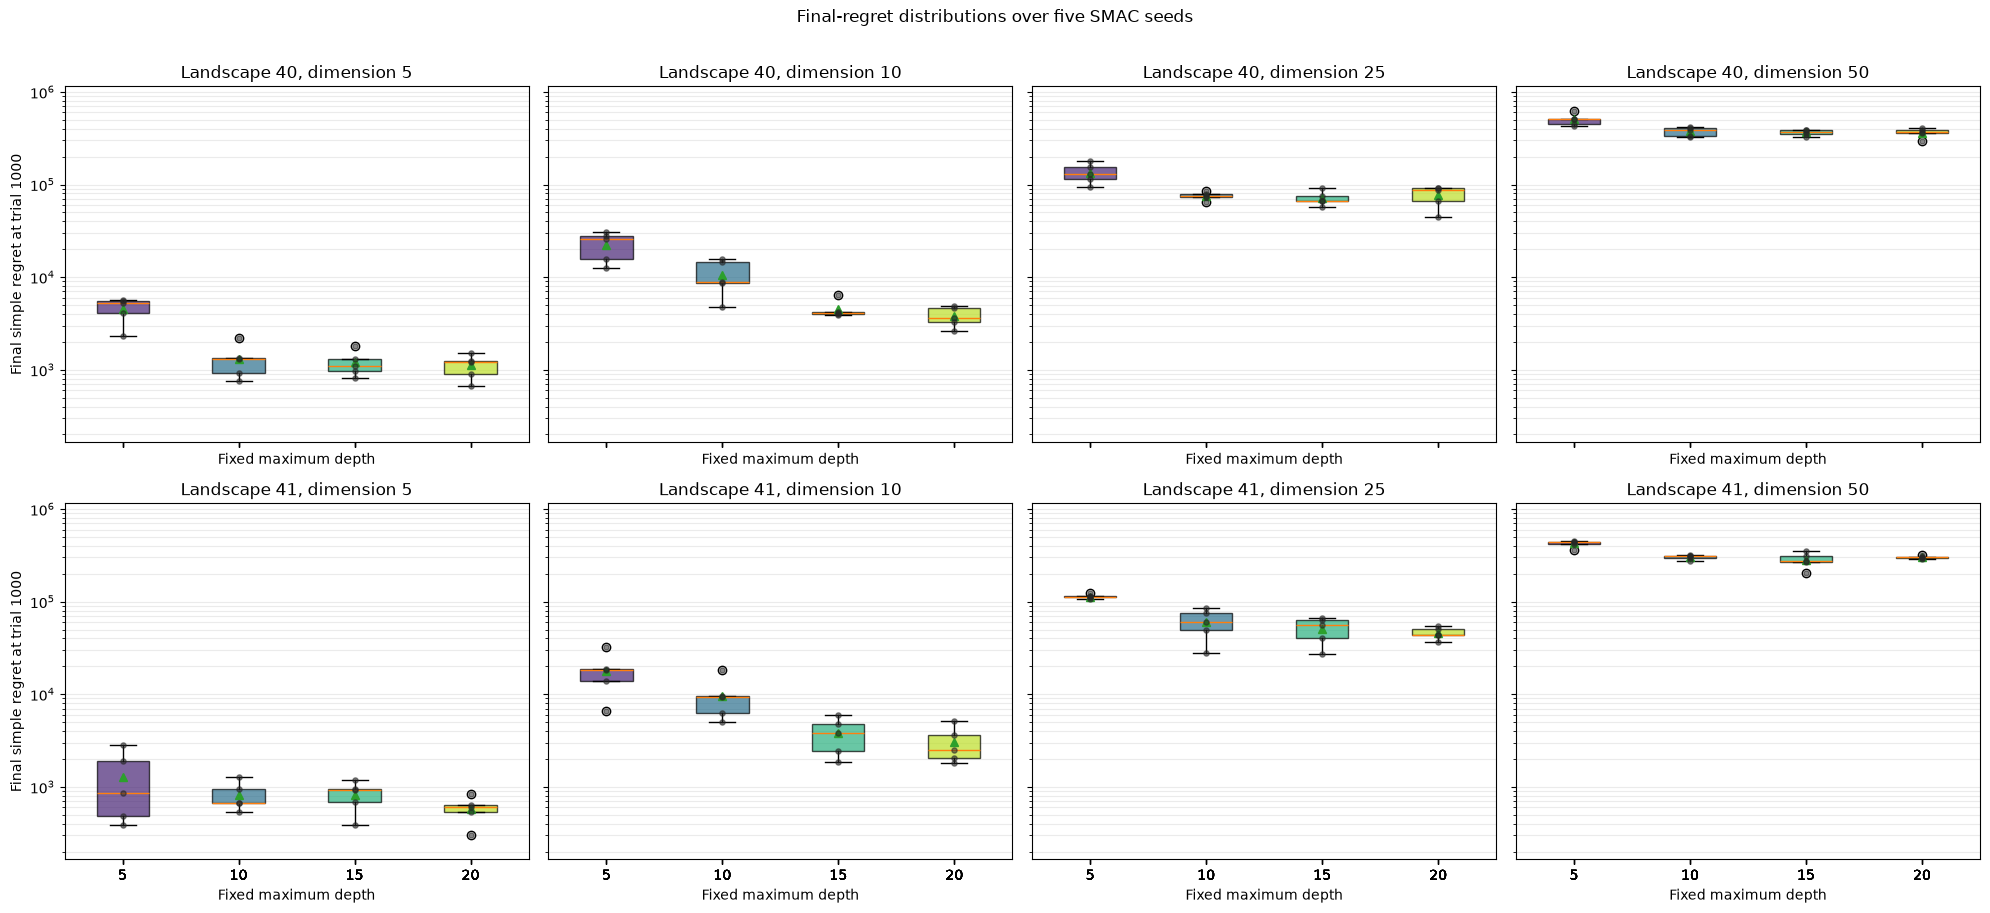

In [6]:
final_y_limits = padded_log_limits([results.final_regret.to_numpy()])
fig, axes = plt.subplots(
    len(BENCHMARK_SEEDS), len(DIMENSIONS),
    figsize=(20, 9), sharex=True, sharey=True,
)
for row, benchmark_seed in enumerate(BENCHMARK_SEEDS):
    for column, dimension in enumerate(DIMENSIONS):
        ax = axes[row, column]
        subset = results.query(
            'benchmark_seed == @benchmark_seed and dimension == @dimension'
        )
        values = [
            subset.query('depth == @depth').sort_values('smac_seed').final_regret.to_numpy()
            for depth in DEPTHS
        ]
        boxes = ax.boxplot(
            values, tick_labels=[str(depth) for depth in DEPTHS],
            showmeans=True, patch_artist=True,
        )
        for position, (box, depth, depth_values) in enumerate(
            zip(boxes['boxes'], DEPTHS, values), start=1
        ):
            box.set_facecolor(colors[depth])
            box.set_alpha(0.7)
            ax.scatter(
                np.full(len(depth_values), position), depth_values,
                color='0.15', alpha=0.55, s=14, zorder=3,
            )
        ax.set_yscale('log')
        ax.set_ylim(*final_y_limits)
        ax.set_title(f'Landscape {benchmark_seed}, dimension {dimension}')
        ax.set_xlabel('Fixed maximum depth')
        ax.set_ylabel('Final simple regret at trial 1000' if column == 0 else '')
        ax.grid(axis='y', alpha=0.25, which='both')
fig.suptitle('Final-regret distributions over five SMAC seeds', y=1.01)
fig.tight_layout()
plt.show()


## Numerical summary

,benchmark_seed,dimension,depth,runs,mean_final,median_final,std_final,mean_log_auc,mean_regret,rank_within_condition
3,40,5,20,5,1110.699898,1220.264777,332.298337,3.370546,6336.059076,1.0
2,40,5,15,5,1197.386861,1102.689459,388.699835,3.367693,6304.361558,2.0
1,40,5,10,5,1312.037589,1308.619479,562.901272,3.403594,6433.043352,3.0
0,40,5,5,5,4559.612334,5261.001436,1414.894804,3.752461,8524.105860,4.0
7,40,10,20,5,3825.493200,3660.974481,944.573803,4.195719,29825.390491,1.0
6,40,10,15,5,4539.239286,4088.406101,1078.240443,4.165491,29335.527435,2.0
5,40,10,10,5,10548.892902,8870.161244,4566.101860,4.278904,31491.861267,3.0
4,40,10,5,5,22492.568287,26065.436631,7930.280026,4.485263,39780.989790,4.0
10,40,25,15,5,71481.821474,67184.169779,12511.561277,5.204528,185739.264673,1.0
9,40,25,10,5,75241.254829,74681.096372,7415.643504,5.186290,179580.084489,2.0


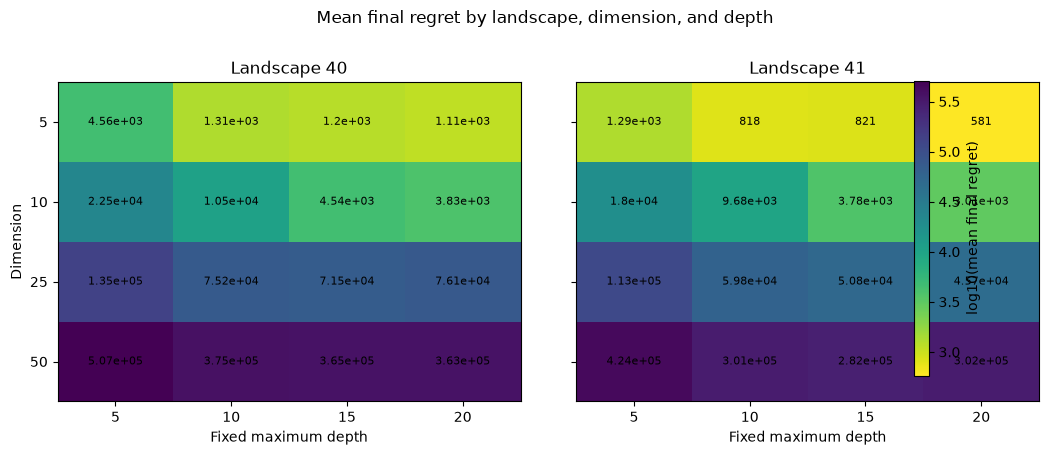

In [7]:
summary = (
    results.groupby(['benchmark_seed', 'dimension', 'depth'], as_index=False)
    .agg(
        runs=('smac_seed', 'nunique'),
        mean_final=('final_regret', 'mean'),
        median_final=('final_regret', 'median'),
        std_final=('final_regret', 'std'),
        mean_log_auc=('log_auc', 'mean'),
        mean_regret=('mean_regret', 'mean'),
    )
)
summary['rank_within_condition'] = (
    summary.groupby(['benchmark_seed', 'dimension']).mean_final
    .rank(method='average')
)
display(summary.sort_values(['benchmark_seed', 'dimension', 'mean_final']))

fig, axes = plt.subplots(1, len(BENCHMARK_SEEDS), figsize=(13, 4.5), sharex=True, sharey=True)
all_means = summary.mean_final.to_numpy()
vmin, vmax = np.log10(all_means.min()), np.log10(all_means.max())
for ax, benchmark_seed in zip(axes, BENCHMARK_SEEDS):
    matrix = (
        summary.query('benchmark_seed == @benchmark_seed')
        .pivot(index='dimension', columns='depth', values='mean_final')
        .reindex(index=DIMENSIONS, columns=DEPTHS)
    )
    image = ax.imshow(np.log10(matrix), aspect='auto', cmap='viridis_r', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(DEPTHS)), DEPTHS)
    ax.set_yticks(range(len(DIMENSIONS)), DIMENSIONS)
    ax.set_xlabel('Fixed maximum depth')
    ax.set_ylabel('Dimension' if ax is axes[0] else '')
    ax.set_title(f'Landscape {benchmark_seed}')
    for row in range(len(DIMENSIONS)):
        for column in range(len(DEPTHS)):
            ax.text(column, row, f'{matrix.iloc[row, column]:.3g}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=axes, label='log10(mean final regret)', shrink=0.85)
fig.suptitle('Mean final regret by landscape, dimension, and depth')
fig.subplots_adjust(top=0.82, right=0.88, wspace=0.12)
plt.show()
